# Machine Learning for CICY 4-Folds

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
import time
import gzip
import json
import gc
from IPython.display import Image
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from tensorflow import keras
from nn_tools.nn_models.models import *
from nn_tools.nn_models.callbacks import *

import warnings
warnings.filterwarnings('ignore', message='The objective has been evaluated at this point before.')

# set matplot
sns.set()
PREFIX = 'cicy4_'
SUFFIX = '_inception'

# set memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
        
# set random seed
RAND = 123
np.random.seed(RAND)
tf.random.set_seed(RAND)
#tf.compat.v1.set_random_seed(RAND)

In [2]:
proot = lambda s: os.path.join('.', s)
pdata = lambda s: os.path.join(proot('data'), s)
pimg  = lambda s: os.path.join(proot('img'), s)
ppred = lambda s: os.path.join(proot('pred'), s)
plogs = lambda s: os.path.join(proot('logs'), s)

os.makedirs(proot('data'), exist_ok=True)
os.makedirs(proot('img'), exist_ok=True)
os.makedirs(proot('pred'), exist_ok=True)
os.makedirs(proot('logs'), exist_ok=True)

## Download and Read the Dataset

In [3]:
data = keras.utils.get_file('cicy4_eng.json.gz',
                            'https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz',
                            cache_dir='.',
                            cache_subdir='data'
                           )

## Reading the Dataset

In [4]:
df = pd.read_json(pdata('cicy4_eng.json.gz'), orient='index')

In [5]:
# select only non product manifolds
df = df.loc[df['isprod'] == False]

# select only complete entries
df = df.dropna()

## Plots

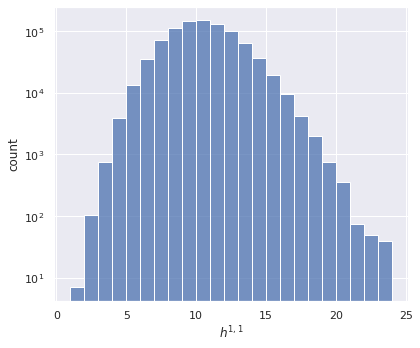

In [6]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=df,
             x='h11',
             stat='count',
             binwidth=1,
             ax=ax
            )
ax.set_xlabel('$h^{1,1}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

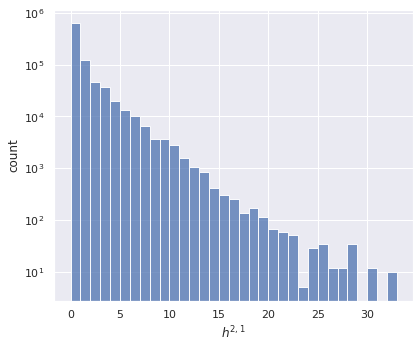

In [7]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=df,
             x='h21',
             stat='count',
             binwidth=1,
             ax=ax
            )
ax.set_xlabel('$h^{2,1}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

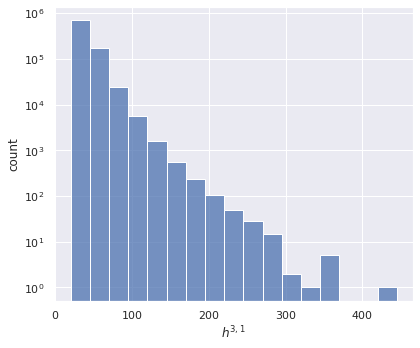

In [8]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=df,
             x='h31',
             stat='count',
             binwidth=25,
             ax=ax
            )
ax.set_xlabel('$h^{3,1}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

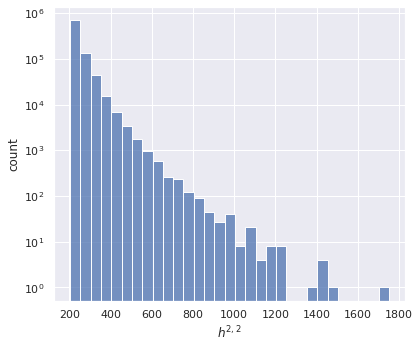

In [9]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=df,
             x='h22',
             stat='count',
             binwidth=50,
             ax=ax
            )
ax.set_xlabel('$h^{2,2}$')
ax.set_ylabel('count')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_distribution' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Correlations

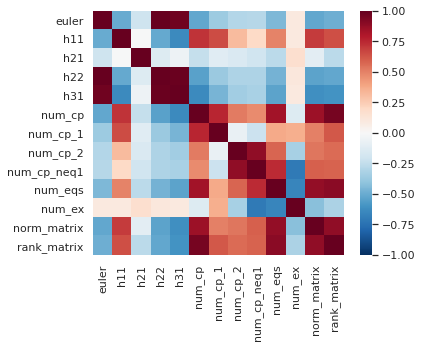

In [10]:
corr = df[['euler',
           'h11',
           'h21',
           'h22',
           'h31',
           'num_cp',
           'num_cp_1',
           'num_cp_2',
           'num_cp_neq1',
           'num_eqs',
           'num_ex',
           'norm_matrix',
           'rank_matrix'
          ]
         ].corr()

_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.heatmap(corr,
            vmin=-1.0,
            vmax=1.0,
            cmap='RdBu_r',
            center=0.0
           )

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'correlations' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Distributions

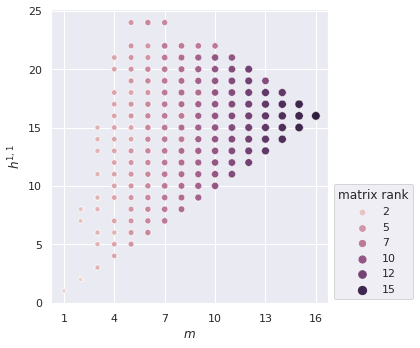

In [11]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(data=df,
                x='num_cp',
                y='h11',
                size='rank_matrix',
                hue='rank_matrix',
                ci=None,
                ax=ax
               )
ax.set_xlabel('$m$')
ax.set_ylabel('$h^{1,1}$')
ax.set_xticks(np.arange(np.min(df['num_cp']), np.max(df['num_cp'])+1, 3))
ax.legend(title='matrix rank', bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_distr_scatter' + SUFFIX + '.pdf'), dpi=150, format='pdf')

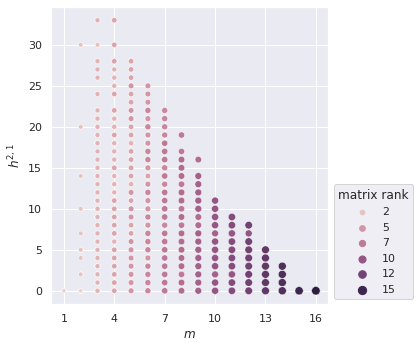

In [12]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(data=df,
                x='num_cp',
                y='h21',
                size='rank_matrix',
                hue='rank_matrix',
                ci=None,
                ax=ax
               )
ax.set_xlabel('$m$')
ax.set_ylabel('$h^{2,1}$')
ax.set_xticks(np.arange(np.min(df['num_cp']), np.max(df['num_cp'])+1, 3))
ax.legend(title='matrix rank', bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_distr_scatter' + SUFFIX + '.pdf'), dpi=150, format='pdf')

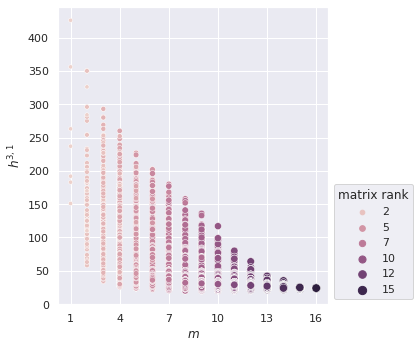

In [13]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(data=df,
                x='num_cp',
                y='h31',
                size='rank_matrix',
                hue='rank_matrix',
                ci=None,
                ax=ax
               )
ax.set_xlabel('$m$')
ax.set_ylabel('$h^{3,1}$')
ax.set_xticks(np.arange(np.min(df['num_cp']), np.max(df['num_cp'])+1, 3))
ax.legend(title='matrix rank', bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_distr_scatter' + SUFFIX + '.pdf'), dpi=150, format='pdf')

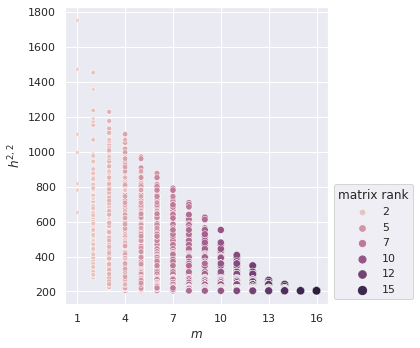

In [14]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(data=df,
                x='num_cp',
                y='h22',
                size='rank_matrix',
                hue='rank_matrix',
                ci=None,
                ax=ax
               )
ax.set_xlabel('$m$')
ax.set_ylabel('$h^{2,2}$')
ax.set_xticks(np.arange(np.min(df['num_cp']), np.max(df['num_cp'])+1, 3))
ax.legend(title='matrix rank', bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_distr_scatter' + SUFFIX + '.pdf'), dpi=150, format='pdf')

## Train, Validation, Test Splits

In [15]:
# get the max shape of the matrix
shape = df['size'].max()

# get the max length
dim_cp_shape  = df['dim_cp'].apply(np.shape).max()
deg_eqs_shape = df['deg_eqs'].apply(np.shape).max()

In [16]:
df_train, df_test = train_test_split(df, test_size=0.02, shuffle=True, random_state=RAND)
df_val, df_test   = train_test_split(df_test, test_size=0.5, shuffle=True, random_state=RAND)

print(f'Training set:   {df_train.shape[0]:d} samples (fraction: {df_train.shape[0] / df.shape[0]:.3f})')
print(f'Validation set: {df_val.shape[0]:d} samples (fraction: {df_val.shape[0] / df.shape[0]:.3f})')
print(f'Test set:       {df_test.shape[0]:d} samples (fraction: {df_test.shape[0] / df.shape[0]:.3f})')

Training set:   887570 samples (fraction: 0.980)
Validation set: 9057 samples (fraction: 0.010)
Test set:       9057 samples (fraction: 0.010)


## Remove Outliers from Train Set

In [17]:
#low_quantile  = 0.05
#high_quantile = 0.95
#
#quantile = df_train.quantile(q=[low_quantile, high_quantile])
#quantile

In [18]:
#df_train = df_train.loc[(df_train['h11'] >= quantile['h11'].loc[low_quantile]) & (df_train['h11'] <= quantile['h11'].loc[high_quantile])
#                        & (df_train['h21'] >= quantile['h21'].loc[low_quantile]) & (df_train['h21'] <= quantile['h21'].loc[high_quantile])
#                        & (df_train['h31'] >= quantile['h31'].loc[low_quantile]) & (df_train['h31'] <= quantile['h31'].loc[high_quantile])
#                        & (df_train['h22'] >= quantile['h22'].loc[low_quantile]) & (df_train['h22'] <= quantile['h22'].loc[high_quantile])
#                       ]
#df_train.info()

## Add Permutations

In [19]:
## number of permutation runs to perform
#n_runs = 2
#
## add permutations
#for _ in range(n_runs):
#    df_new           = df_train.copy()
#    df_new['matrix'] = df_new['matrix'].apply(lambda M: np.transpose(np.random.permutation(np.transpose(np.random.permutation(M)))))
#    df_train         = df_train.append(df_new, ignore_index=True)
#    del df_new

In [20]:
#print(f'New training set size: {df_train.shape}')

In [21]:
#df_train.info()

## Save Sets to File

In [22]:
df_train.to_csv(pdata(PREFIX + 'train_set' + SUFFIX + '.csv.gz'), index=False)
df_val.to_csv(pdata(PREFIX + 'val_set' + SUFFIX + '.csv.gz'), index=False)
df_test.to_csv(pdata(PREFIX + 'test_set' + SUFFIX + '.csv.gz'), index=False)

## Building the Configuration Matrices (Sparse to Dense)

In [23]:
# get the offset and pad the matrix
offset = lambda s: [(0, shape[i] - np.shape(s)[i]) for i in range(len(shape))]
df_train['matrix'] = df_train['matrix'].apply(lambda s: np.pad(s, offset(s), mode='constant'))
df_val['matrix']   = df_val['matrix'].apply(lambda s: np.pad(s, offset(s), mode='constant'))
df_test['matrix']  = df_test['matrix'].apply(lambda s: np.pad(s, offset(s), mode='constant'))

<ipython-input-23-9f0c6ebceeb4>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['matrix'] = df_train['matrix'].apply(lambda s: np.pad(s, offset(s), mode='constant'))


## Building the Vector Features (Sparse to Dense)

In [24]:
## get the offset and pad
#offset_dim_cp = lambda s: (0, dim_cp_shape[0] - np.shape(s)[0])
#df_train['dim_cp']  = df_train['dim_cp'].apply(lambda s: np.pad(s, offset_dim_cp(s), mode='constant'))
#df_val['dim_cp']    = df_val['dim_cp'].apply(lambda s: np.pad(s, offset_dim_cp(s), mode='constant'))
#df_test['dim_cp']   = df_test['dim_cp'].apply(lambda s: np.pad(s, offset_dim_cp(s), mode='constant'))

#offset_deg_eqs = lambda s: (0, deg_eqs_shape[0] - np.shape(s)[0])
#df_train['deg_eqs']   = df_train['deg_eqs'].apply(lambda s: np.pad(s, offset_deg_eqs(s), mode='constant'))
#df_val['deg_eqs']     = df_val['deg_eqs'].apply(lambda s: np.pad(s, offset_deg_eqs(s), mode='constant'))
#df_test['deg_eqs']    = df_test['deg_eqs'].apply(lambda s: np.pad(s, offset_deg_eqs(s), mode='constant'))

## Rescale the Matrices

In [25]:
scale = df_train['matrix'].apply(np.max).max()

In [26]:
df_train['matrix'] = df_train['matrix'] / scale
df_val['matrix']   = df_val['matrix'] / scale
df_test['matrix']  = df_test['matrix'] / scale

<ipython-input-26-96f5e4928d09>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['matrix'] = df_train['matrix'] / scale


## Reshape Layers for CNN

In [27]:
reshape = tuple(shape + [1])

In [28]:
df_train['matrix'] = df_train['matrix'].apply(lambda x: np.reshape(x, reshape))
df_val['matrix']   = df_val['matrix'].apply(lambda x: np.reshape(x, reshape))
df_test['matrix']  = df_test['matrix'].apply(lambda x: np.reshape(x, reshape))

<ipython-input-28-65825c2fed84>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['matrix'] = df_train['matrix'].apply(lambda x: np.reshape(x, reshape))


## Create Dataset Generators

In [29]:
train_features = {'matrix': np.array([df_train['matrix'].iloc[n] for n in range(df_train.shape[0])]),
                  #'scalars': np.array([df_train[['num_cp', 'num_cp_1', 'num_cp_2', 'num_cp_neq1', 'norm_matrix', 'rank_matrix', 'num_eqs', 'num_ex']].iloc[n] for n in range(df_train.shape[0])]),
                  #'dim_cp': np.array([df_train['dim_cp'].iloc[n] for n in range(df_train.shape[0])]),
                  #'deg_eqs': np.array([df_train['deg_eqs'].iloc[n] for n in range(df_train.shape[0])])
                 }
val_features = {'matrix': np.array([df_val['matrix'].iloc[n] for n in range(df_val.shape[0])]),
                #'scalars': np.array([df_val[['num_cp', 'num_cp_1', 'num_cp_2', 'num_cp_neq1', 'norm_matrix', 'rank_matrix', 'num_eqs', 'num_ex']].iloc[n] for n in range(df_val.shape[0])]),
                #'dim_cp': np.array([df_val['dim_cp'].iloc[n] for n in range(df_val.shape[0])]),
                #'deg_eqs': np.array([df_val['deg_eqs'].iloc[n] for n in range(df_val.shape[0])])
               }
test_features = {'matrix': np.array([df_test['matrix'].iloc[n] for n in range(df_test.shape[0])]),
                 #'scalars': np.array([df_test[['num_cp', 'num_cp_1', 'num_cp_2', 'num_cp_neq1', 'norm_matrix', 'rank_matrix', 'num_eqs', 'num_ex']].iloc[n] for n in range(df_test.shape[0])]),
                 #'dim_cp': np.array([df_test['dim_cp'].iloc[n] for n in range(df_test.shape[0])]),
                 #'deg_eqs': np.array([df_test['deg_eqs'].iloc[n] for n in range(df_test.shape[0])])
                }

In [30]:
#scalars_shape = train_features['scalars'][0].shape

In [31]:
train_labels = {'h11': np.array(df_train['h11'].values.astype(np.int)),
                'h21': np.array(df_train['h21'].values.astype(np.int)),
                'h31': np.array(df_train['h31'].values.astype(np.int)),
                'h22': np.array(df_train['h22'].values.astype(np.int)),
               }
val_labels = {'h11': np.array(df_val['h11'].values.astype(np.int)),
              'h21': np.array(df_val['h21'].values.astype(np.int)),
              'h31': np.array(df_val['h31'].values.astype(np.int)),
              'h22': np.array(df_val['h22'].values.astype(np.int)),
             }
test_labels = {'h11': np.array(df_test['h11'].values.astype(np.int)),
               'h21': np.array(df_test['h21'].values.astype(np.int)),
               'h31': np.array(df_test['h31'].values.astype(np.int)),
               'h22': np.array(df_test['h22'].values.astype(np.int)),
              }

## Model Building

### Inception Network

In [32]:
matrix = nn_inception(input_shape=reshape,
                      name='matrix',
                      learning_rate=1.0e-3,
                      conv_1b1=False,
                      conv_layers=[32, 64, 32],
                      conv_alpha=0.0,
                      conv_class=None,
                      conv_single=False,
                      conv_red=0,
                      feat_map=0,
                      recurrent=False,
                      fc_layers=[100],
                      fc_alpha=0.0,
                      dropout=0.25,
                      full_dropout=0.0,
                      batchnorm=0.99,
                      last_relu=True,
                      loss_weights=[0.15, 0.20, 0.30, 0.35],
                      l1_reg=1.0e-3,
                      l2_reg=1.0e-4,
                      output_layers=True
                      #output_layers=False
                     )

matrix.summary()

Model: "matrix"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
matrix (InputLayer)             [(None, 16, 20, 1)]  0                                            
__________________________________________________________________________________________________
matrix_convAa_0 (Conv2D)        (None, 16, 20, 32)   544         matrix[0][0]                     
__________________________________________________________________________________________________
matrix_convAb_0 (Conv2D)        (None, 16, 20, 32)   672         matrix[0][0]                     
__________________________________________________________________________________________________
matrix_actAa_0 (LeakyReLU)      (None, 16, 20, 32)   0           matrix_convAa_0[0][0]            
_____________________________________________________________________________________________

In [33]:
# TensorFlow v1
#keras.utils.plot_model(matrix,
#                       to_file=pimg(PREFIX + 'matrix_graph' + SUFFIX + '.png'),
#                       show_shapes=True
#                      )

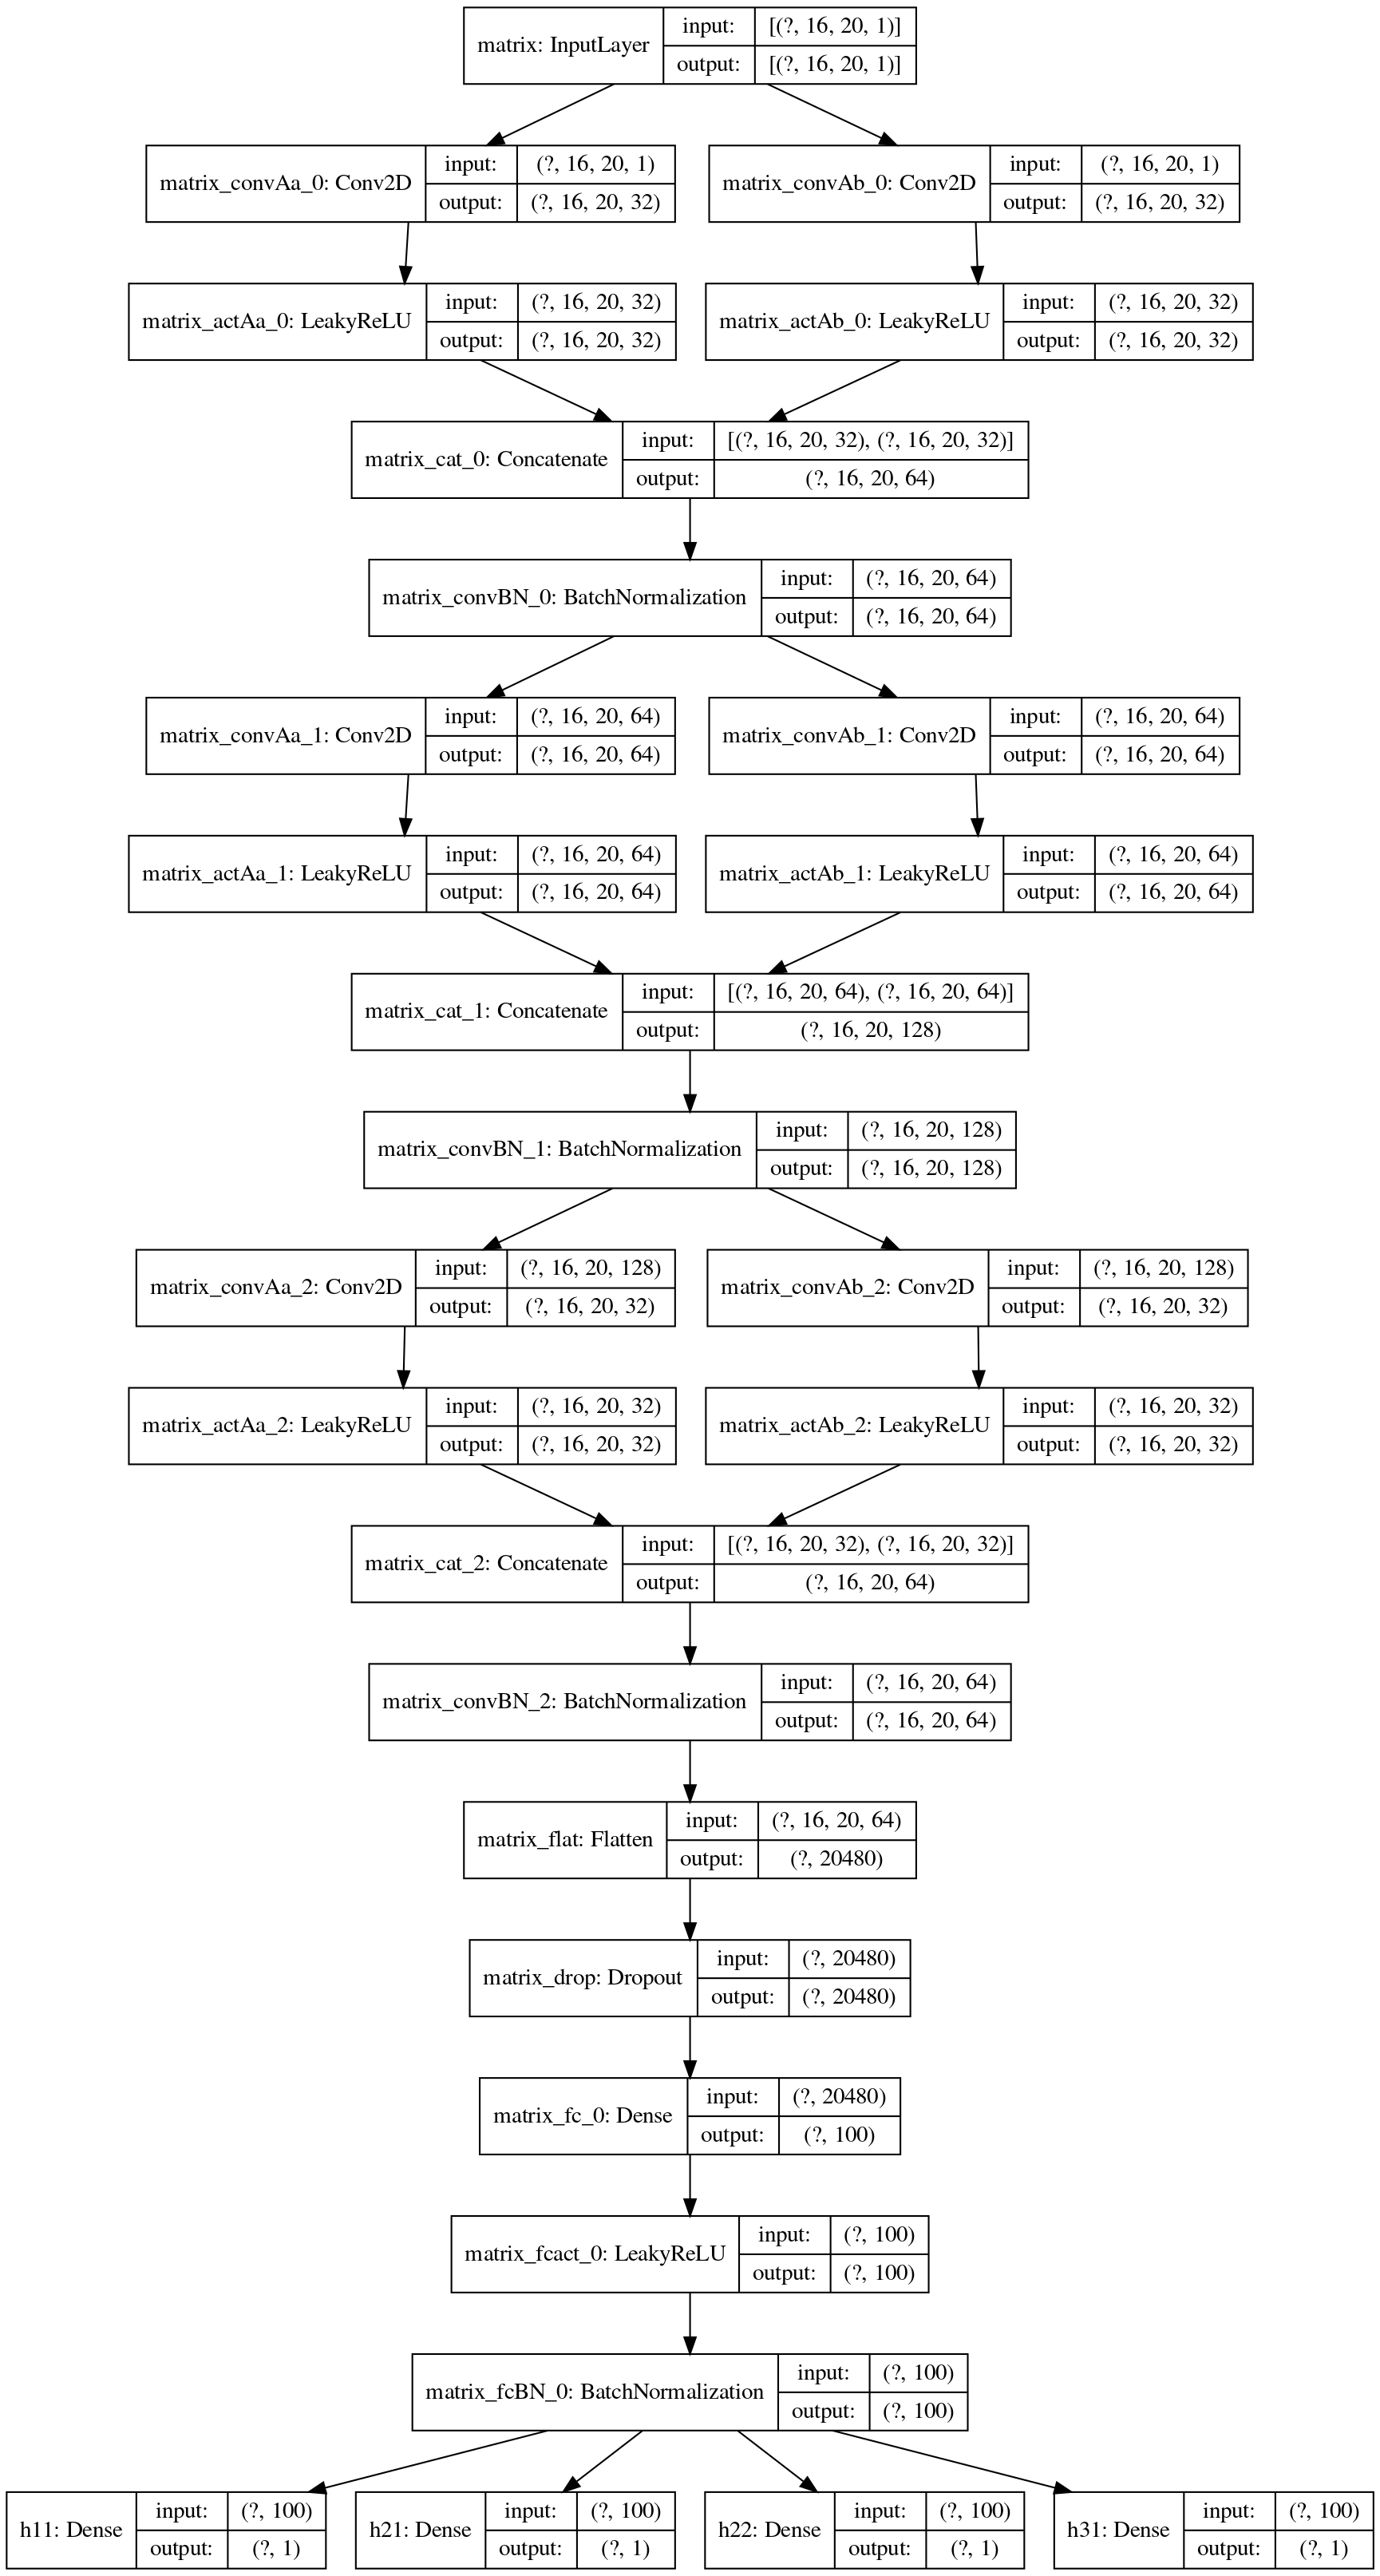

In [34]:
# TensorFlow v2
matrix_graph = keras.utils.model_to_dot(matrix, show_shapes=True, dpi=150)
matrix_graph.write_pdf(pimg(PREFIX + 'matrix_graph' + SUFFIX + '.pdf'))
Image(matrix_graph.create_png(), width=480)

### Dense Network

In [35]:
#scalars = nn_dense(input_shape=scalars_shape,
#                   name='scalars',
#                   learning_rate=1.0e-3,
#                   recurrent=False,
#                   fc_layers=[10, 10, 5],
#                   fc_alpha=0.0,
#                   dropout=0.1,
#                   batchnorm=0.99,
#                   last_relu=True,
#                   loss_weights=[0.25, 0.25, 0.25, 0.25],
#                   l1_reg=1.0e-5,
#                   l2_reg=1.0e-5,
#                   output_layers=True
#                   #output_layers=False
#                  )
#
#scalars.summary()

In [36]:
# TensorFlow v1
#keras.utils.plot_model(scalars,
#                       to_file=pimg(PREFIX + 'scalars_graph' + SUFFIX + '.png'),
#                       show_shapes=True
#                      )

In [37]:
# TensorFlow v2
#scalars_graph = keras.utils.model_to_dot(scalars, show_shapes=True, dpi=150)
#scalars_graph.write_pdf(pimg(PREFIX + 'scalars_graph' + SUFFIX + '.pdf'))
#Image(scalars_graph.create_png(), width=480)

In [38]:
#dim_cp = nn_dense(input_shape=dim_cp_shape,
#                  name='dim_cp',
#                  learning_rate=1.0e-3,
#                  recurrent=False,
#                  fc_layers=[20, 10, 5],
#                  fc_alpha=0.0,
#                  dropout=0.1,
#                  batchnorm=0.99,
#                  last_relu=True,
#                  loss_weights=[0.25, 0.25, 0.25, 0.25],
#                  l1_reg=1.0e-5,
#                  l2_reg=1.0e-5,
#                  output_layers=True
#                  #output_layers=False
#                 )
#
#dim_cp.summary()

In [39]:
# TensorFlow v1
#keras.utils.plot_model(dim_cp,
#                       to_file=pimg(PREFIX + 'dim_cp_graph' + SUFFIX + '.png'),
#                       show_shapes=True
#                      )

In [40]:
# TensorFlow v2
#dim_cp_graph = keras.utils.model_to_dot(dim_cp, show_shapes=True, dpi=150)
#dim_cp_graph.write_pdf(pimg(PREFIX + 'dim_cp_graph' + SUFFIX + '.pdf'))
#Image(dim_cp_graph.create_png(), width=480)

In [41]:
#deg_eqs = nn_dense(input_shape=deg_eqs_shape,
#                   name='deg_eqs',
#                   learning_rate=1.0e-3,
#                   recurrent=False,
#                   fc_layers=[20, 10, 5],
#                   fc_alpha=0.0,
#                   dropout=0.1,
#                   batchnorm=0.99,
#                   last_relu=True,
#                   loss_weights=[0.25, 0.25, 0.25, 0.25],
#                   l1_reg=1.0e-5,
#                   l2_reg=1.0e-5,
#                   output_layers=True
#                   #output_layers=False
#                  )
#
#deg_eqs.summary()

In [42]:
# TensorFlow v1
#keras.utils.plot_model(deg_eqs,
#                       to_file=pimg(PREFIX + 'deg_eqs_graph' + SUFFIX + '.png'),
#                       show_shapes=True
#                      )

In [43]:
# TensorFlow v2
#deg_eqs_graph = keras.utils.model_to_dot(deg_eqs, show_shapes=True, dpi=150)
#deg_eqs_graph.write_pdf(pimg(PREFIX + 'deg_eqs_graph' + SUFFIX + '.pdf'))
#Image(deg_eqs_graph.create_png(), width=480)

### Full Model

In [44]:
#full_model = nn_full([matrix, scalars, dim_cp, deg_eqs],
#                     name='full_model',
#                     learning_rate=1.0e-3,
#                     last_relu=True,
#                     fc_layers=[20],
#                     fc_alpha=0.0,
#                     batchnorm=0.99,
#                     dropout=0.0,
#                     loss_weights=[0.25, 0.25, 0.25, 0.25],
#                     l1_reg=0.0,
#                     l2_reg=0.0
#                    )
#full_model.summary()

In [45]:
# TensorFlow v1
#keras.utils.plot_model(full_model,
#                       to_file=pimg(PREFIX + 'full_model_graph' + SUFFIX + '.png'),
#                       show_shapes=True
#                      )

In [46]:
# TensorFlow v2
#full_model_graph = keras.utils.model_to_dot(full_model, show_shapes=True, dpi=150)
#full_model_graph.write_pdf(pimg(PREFIX + 'full_model_graph' + SUFFIX + '.pdf'))
#Image(full_model_graph.create_png(), width=480)

## Training the Model

In [47]:
epochs   = 25
interval = int(epochs / 10) if epochs > 10 else 1

In [48]:
batch_size = 64

In [49]:
full_model = matrix
full_model_hst = full_model.fit(x=train_features,
                                y=train_labels,
                                batch_size=batch_size,
                                epochs=epochs,
                                verbose=0,
                                callbacks=[keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'inception' + SUFFIX + '.h5'),
                                                                           monitor='val_loss',
                                                                           save_best_only=True
                                                                          ),
                                           keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'h11_inception' + SUFFIX + '.h5'),
                                                                           monitor='val_h11_loss',
                                                                           save_best_only=True
                                                                          ),
                                           keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'h21_inception' + SUFFIX + '.h5'),
                                                                           monitor='val_h21_loss',
                                                                           save_best_only=True
                                                                          ),
                                           keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'h31_inception' + SUFFIX + '.h5'),
                                                                           monitor='val_h31_loss',
                                                                           save_best_only=True
                                                                          ),
                                           keras.callbacks.ModelCheckpoint(pdata(PREFIX + 'h22_inception' + SUFFIX + '.h5'),
                                                                           monitor='val_h22_loss',
                                                                           save_best_only=True
                                                                          ),
                                           #keras.callbacks.EarlyStopping(patience=int(epochs/2),
                                           #                              restore_best_weights=True
                                           #                             ),
                                           keras.callbacks.ReduceLROnPlateau(factor=0.1,
                                                                             patience=int(epochs/3),
                                                                             min_lr=1.0e-6
                                                                            ),
                                           keras.callbacks.TensorBoard(log_dir=proot('logs'),
                                                                       histogram_freq=interval,
                                                                       write_graph=True,
                                                                       write_images=True,
                                                                       update_freq='epoch',
                                                                       profile_batch=2,
                                                                       embeddings_freq=interval,
                                                                       embeddings_metadata=None
                                                                      ),
                                           PrintCheckpoint(interval)
                                          ],
                                validation_data=(val_features, val_labels)
                               )

Training has started. Callouts will be printed every 2 epochs.

Training epoch 1. Started on 19/09/2020 at 19:40:05.

    Average epoch training time: 294.443 seconds
    loss = 1151.624
    h11_loss = 11.563
    h21_loss = 2.772
    h22_loss = 3640.208
    h31_loss = 84.822
    h11_mean_squared_error = 11.563
    h11_mean_absolute_error = 1.918
    h21_mean_squared_error = 2.772
    h21_mean_absolute_error = 0.916
    h22_mean_squared_error = 3640.208
    h22_mean_absolute_error = 26.291
    h31_mean_squared_error = 84.822
    h31_mean_absolute_error = 4.673
    val_loss = 50.900
    val_h11_loss = 1.246
    val_h21_loss = 2.233
    val_h22_loss = 101.678
    val_h31_loss = 5.187
    val_h11_mean_squared_error = 1.246
    val_h11_mean_absolute_error = 0.786
    val_h21_mean_squared_error = 2.233
    val_h21_mean_absolute_error = 0.704
    val_h22_mean_squared_error = 101.678
    val_h22_mean_absolute_error = 7.020
    val_h31_mean_squared_error = 5.187
    val_h31_mean_absolute_error 

In [50]:
full_model     = keras.models.load_model(pdata(PREFIX + 'inception' + SUFFIX + '.h5'))
full_h11_model = keras.models.load_model(pdata(PREFIX + 'h11_inception' + SUFFIX + '.h5'))
full_h21_model = keras.models.load_model(pdata(PREFIX + 'h21_inception' + SUFFIX + '.h5'))
full_h31_model = keras.models.load_model(pdata(PREFIX + 'h31_inception' + SUFFIX + '.h5'))
full_h22_model = keras.models.load_model(pdata(PREFIX + 'h22_inception' + SUFFIX + '.h5'))

In [51]:
history = pd.DataFrame(full_model_hst.history)

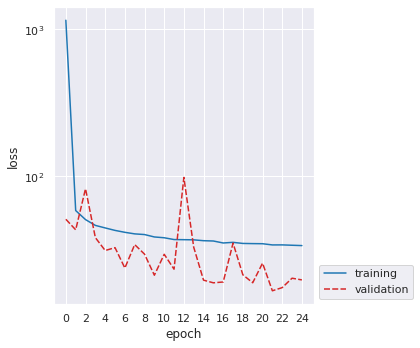

In [52]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['loss', 'val_loss']],
             palette=['tab:blue', 'tab:red'],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_yscale('log')

step = int(epochs / 10) if epochs > 10 else 1
ax.set_xticks(np.arange(0, epochs, step))
ax.legend(['training', 'validation'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'loss_functions' + SUFFIX + '.pdf'), format='pdf', dpi=150)

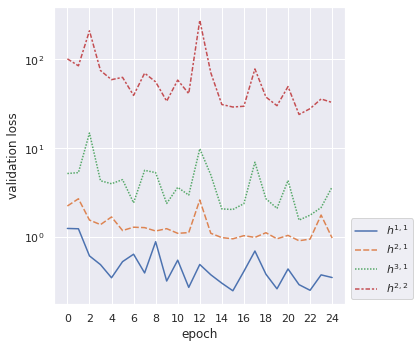

In [53]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['val_h11_loss', 'val_h21_loss', 'val_h31_loss', 'val_h22_loss']],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('validation loss')
ax.set_yscale('log')

step = int(epochs / 10) if epochs > 10 else 1
ax.set_xticks(np.arange(0, epochs, step))
ax.legend(['$h^{1,1}$', '$h^{2,1}$', '$h^{3,1}$', '$h^{2,2}$'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'val_loss_functions' + SUFFIX + '.pdf'), format='pdf', dpi=150)

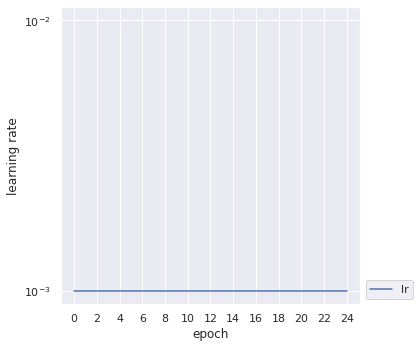

In [54]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.lineplot(data=history[['lr']],
             ax=ax
            )
ax.set_xlabel('epoch')
ax.set_ylabel('learning rate')
ax.set_yscale('log')

step = int(epochs / 10) if epochs > 10 else 1
ax.set_xticks(np.arange(0, epochs, step))
ax.legend(bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'learning_rate' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Full Model

In [55]:
_ = full_model.evaluate(x=test_features, y=test_labels, batch_size=batch_size, verbose=1)

142/142 [==============================] - 1s 6ms/step - loss: 16.7593 - h11_loss: 0.2792 - h21_loss: 0.9682 - h22_loss: 24.4590 - h31_loss: 1.5772 - h11_mean_squared_error: 0.2792 - h11_mean_absolute_error: 0.3681 - h21_mean_squared_error: 0.9682 - h21_mean_absolute_error: 0.4785 - h22_mean_squared_error: 24.4590 - h22_mean_absolute_error: 3.3646 - h31_mean_squared_error: 1.5772 - h31_mean_absolute_error: 0.8725


In [56]:
train_predictions = full_model.predict(train_features)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_model.predict(val_features)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_model.predict(test_features)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '.json'), 'w') as f:
    json.dump(test_predictions, f)

In [57]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '.csv.gz'))
metrics

,train_mse,val_mse,test_mse,train_mae,val_mae,test_mae,train_r2,val_r2,test_r2,train_acc,val_acc,test_acc
h11,0.330954,0.339185,0.320746,0.267631,0.272055,0.260903,0.943684,0.940656,0.946557,0.756071,0.751905,0.762946
h21,0.963592,0.945015,1.004969,0.460742,0.459865,0.465496,0.728015,0.728848,0.715840,0.694020,0.691178,0.694601
h31,2.302511,1.630893,1.660594,0.837505,0.827316,0.835155,0.987771,0.990915,0.991253,0.413405,0.417136,0.411395
h22,33.177293,24.064591,24.569615,3.366297,3.319974,3.361709,0.986523,0.989733,0.990079,0.115592,0.122115,0.118582


In [58]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

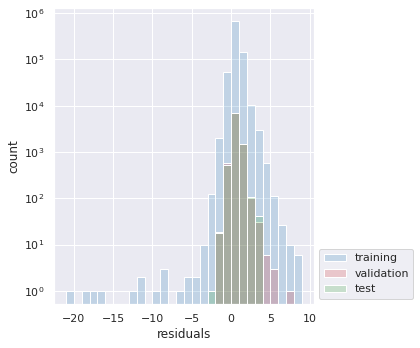

In [59]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h11',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h11',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h11',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

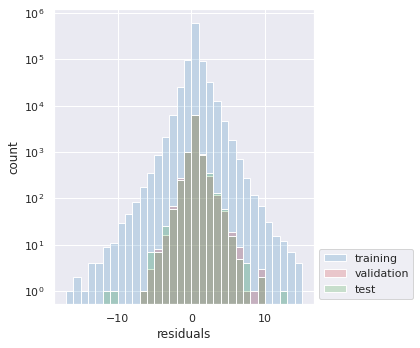

In [60]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h21',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h21',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h21',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

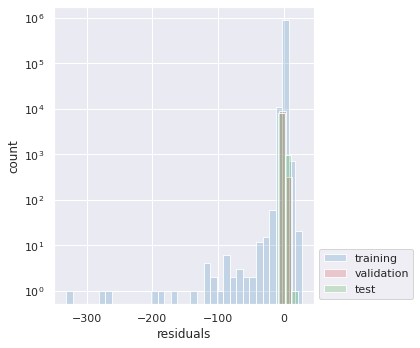

In [61]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h31',
             stat='count',
             color='tab:blue',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h31',
             stat='count',
             color='tab:red',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h31',
             stat='count',
             color='tab:green',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

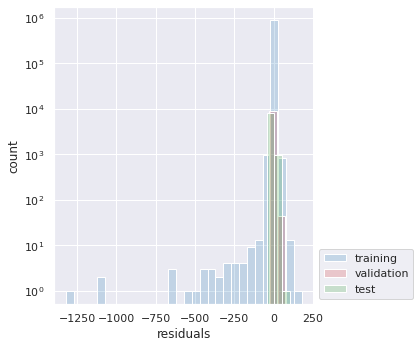

In [62]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h22',
             stat='count',
             color='tab:blue',
             binwidth=50,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h22',
             stat='count',
             color='tab:red',
             binwidth=50,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h22',
             stat='count',
             color='tab:green',
             binwidth=50,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '.pdf'), format='pdf', dpi=150)

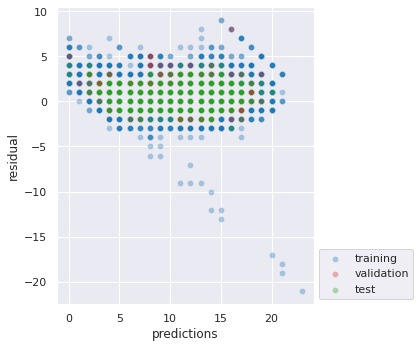

In [63]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

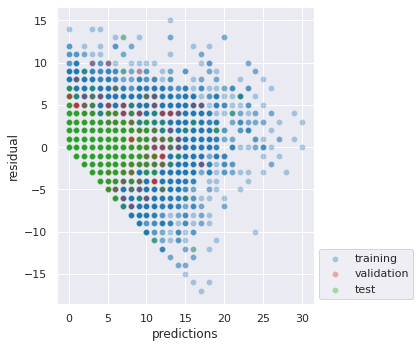

In [64]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

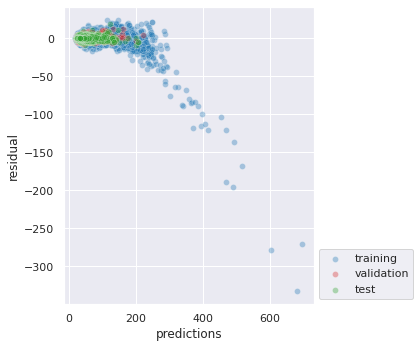

In [65]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

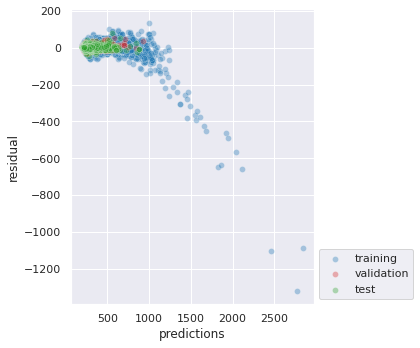

In [66]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Best $h^{1,1}$ Model

In [67]:
_ = full_h11_model.evaluate(x=test_features, y=test_labels, batch_size=batch_size, verbose=1)

142/142 [==============================] - 1s 6ms/step - loss: 19.0882 - h11_loss: 0.2447 - h21_loss: 0.9877 - h22_loss: 29.9397 - h31_loss: 2.1442 - h11_mean_squared_error: 0.2447 - h11_mean_absolute_error: 0.3389 - h21_mean_squared_error: 0.9877 - h21_mean_absolute_error: 0.4852 - h22_mean_squared_error: 29.9397 - h22_mean_absolute_error: 3.7651 - h31_mean_squared_error: 2.1442 - h31_mean_absolute_error: 1.0626


In [68]:
train_predictions = full_h11_model.predict(train_features)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_h11_model.predict(val_features)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_h11_model.predict(test_features)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '_h11_model.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '_h11_model.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '_h11_model.json'), 'w') as f:
    json.dump(test_predictions, f)

In [69]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '_h11_model.csv.gz'))
metrics

,train_mse,val_mse,test_mse,train_mae,val_mae,test_mae,train_r2,val_r2,test_r2,train_acc,val_acc,test_acc
h11,0.287052,0.279121,0.278127,0.227846,0.223032,0.224688,0.951154,0.951165,0.953658,0.794132,0.796621,0.795296
h21,0.993673,0.993707,1.031136,0.466030,0.472342,0.475544,0.719524,0.714877,0.708441,0.695618,0.686982,0.693497
h31,2.198736,2.130507,2.212322,1.019379,1.015347,1.025836,0.988322,0.988132,0.988347,0.340089,0.338412,0.341283
h22,29.158114,29.227890,30.025726,3.728971,3.731810,3.757646,0.988156,0.987530,0.987876,0.102633,0.104670,0.101248


In [70]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

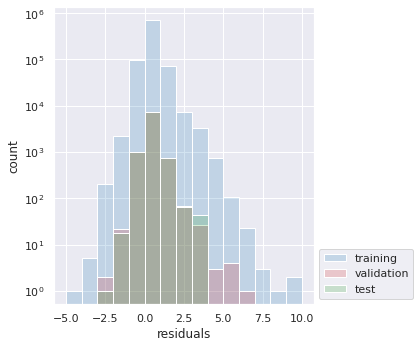

In [71]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h11',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h11',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h11',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

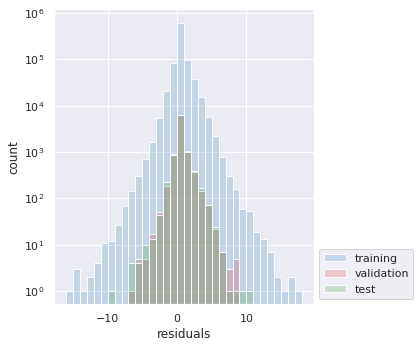

In [72]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h21',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h21',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h21',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

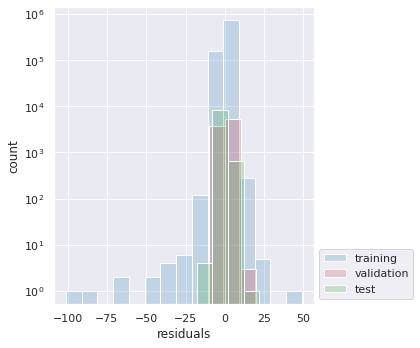

In [73]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h31',
             stat='count',
             color='tab:blue',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h31',
             stat='count',
             color='tab:red',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h31',
             stat='count',
             color='tab:green',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

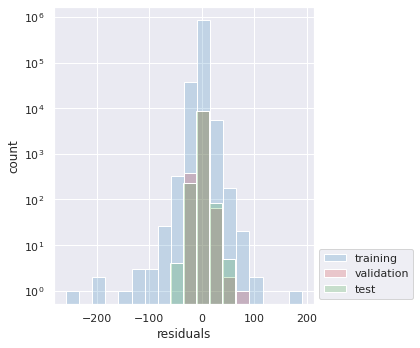

In [74]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h22',
             stat='count',
             color='tab:blue',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h22',
             stat='count',
             color='tab:red',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h22',
             stat='count',
             color='tab:green',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

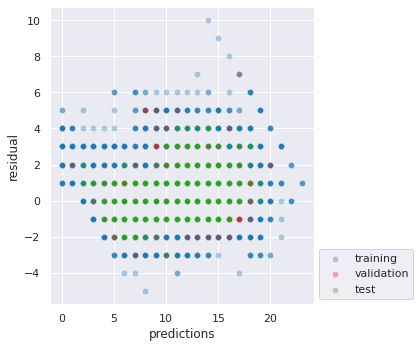

In [75]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

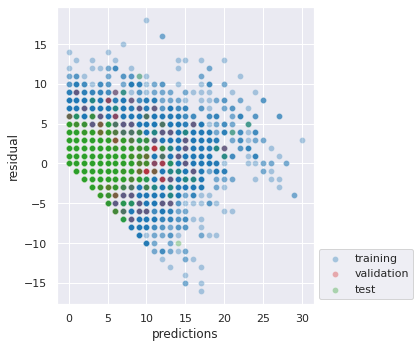

In [76]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

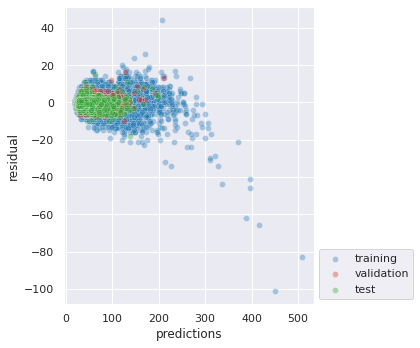

In [77]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

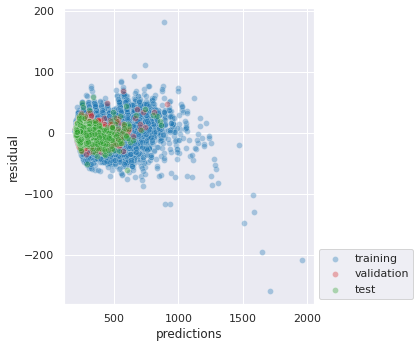

In [78]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '_h11_model.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Best $h^{2,1}$ Model

In [79]:
_ = full_h21_model.evaluate(x=test_features, y=test_labels, batch_size=batch_size, verbose=1)

142/142 [==============================] - 1s 6ms/step - loss: 16.7593 - h11_loss: 0.2792 - h21_loss: 0.9682 - h22_loss: 24.4590 - h31_loss: 1.5772 - h11_mean_squared_error: 0.2792 - h11_mean_absolute_error: 0.3681 - h21_mean_squared_error: 0.9682 - h21_mean_absolute_error: 0.4785 - h22_mean_squared_error: 24.4590 - h22_mean_absolute_error: 3.3646 - h31_mean_squared_error: 1.5772 - h31_mean_absolute_error: 0.8725


In [80]:
train_predictions = full_h21_model.predict(train_features)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_h21_model.predict(val_features)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_h21_model.predict(test_features)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '_h21_model.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '_h21_model.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '_h21_model.json'), 'w') as f:
    json.dump(test_predictions, f)

In [81]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '_h21_model.csv.gz'))
metrics

,train_mse,val_mse,test_mse,train_mae,val_mae,test_mae,train_r2,val_r2,test_r2,train_acc,val_acc,test_acc
h11,0.330954,0.339185,0.320746,0.267631,0.272055,0.260903,0.943684,0.940656,0.946557,0.756071,0.751905,0.762946
h21,0.963592,0.945015,1.004969,0.460742,0.459865,0.465496,0.728015,0.728848,0.715840,0.694020,0.691178,0.694601
h31,2.302511,1.630893,1.660594,0.837505,0.827316,0.835155,0.987771,0.990915,0.991253,0.413405,0.417136,0.411395
h22,33.177293,24.064591,24.569615,3.366297,3.319974,3.361709,0.986523,0.989733,0.990079,0.115592,0.122115,0.118582


In [82]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

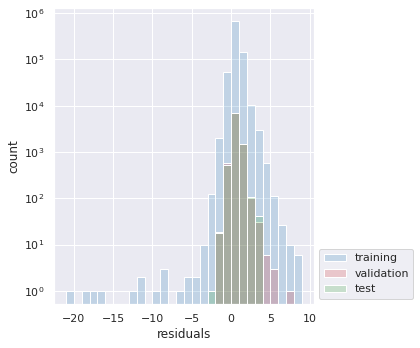

In [83]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h11',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h11',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h11',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

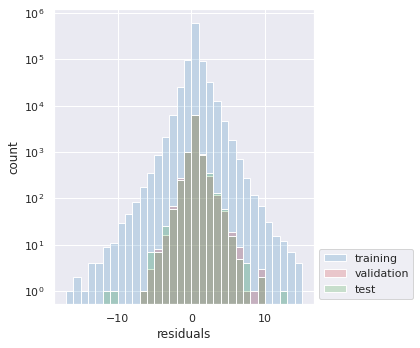

In [84]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h21',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h21',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h21',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

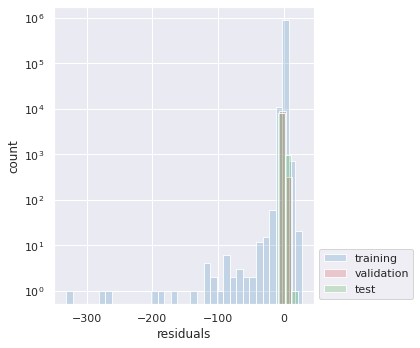

In [85]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h31',
             stat='count',
             color='tab:blue',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h31',
             stat='count',
             color='tab:red',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h31',
             stat='count',
             color='tab:green',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

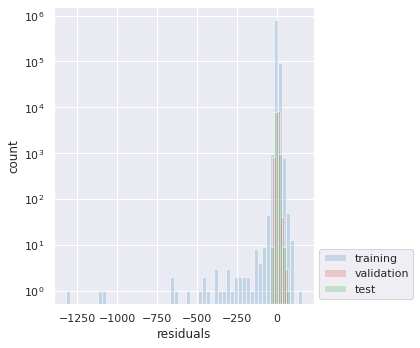

In [86]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h22',
             stat='count',
             color='tab:blue',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h22',
             stat='count',
             color='tab:red',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h22',
             stat='count',
             color='tab:green',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

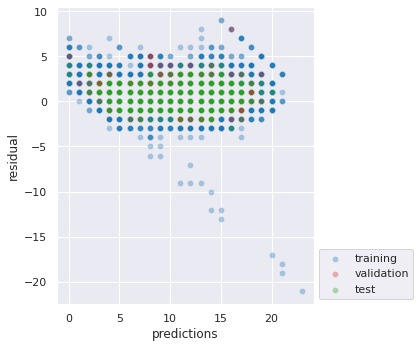

In [87]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

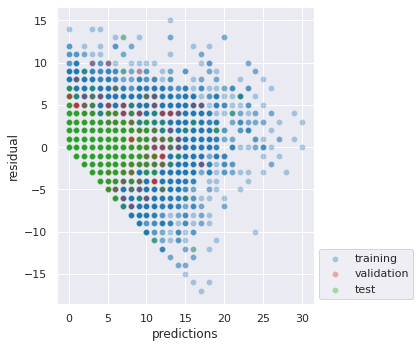

In [88]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

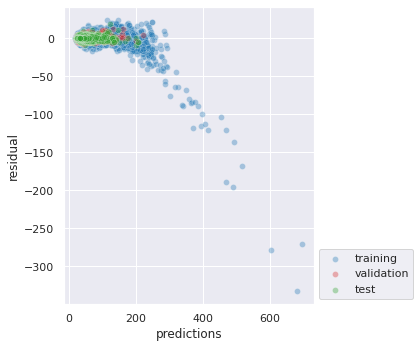

In [89]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

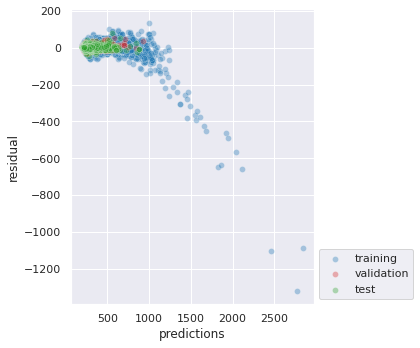

In [90]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '_h21_model.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Best $h^{3,1}$ Model

In [91]:
_ = full_h31_model.evaluate(x=test_features, y=test_labels, batch_size=batch_size, verbose=1)

142/142 [==============================] - 1s 6ms/step - loss: 16.7593 - h11_loss: 0.2792 - h21_loss: 0.9682 - h22_loss: 24.4590 - h31_loss: 1.5772 - h11_mean_squared_error: 0.2792 - h11_mean_absolute_error: 0.3681 - h21_mean_squared_error: 0.9682 - h21_mean_absolute_error: 0.4785 - h22_mean_squared_error: 24.4590 - h22_mean_absolute_error: 3.3646 - h31_mean_squared_error: 1.5772 - h31_mean_absolute_error: 0.8725


In [92]:
train_predictions = full_h31_model.predict(train_features)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_h31_model.predict(val_features)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_h31_model.predict(test_features)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '_h31_model.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '_h31_model.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '_h31_model.json'), 'w') as f:
    json.dump(test_predictions, f)

In [93]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '_h31_model.csv.gz'))
metrics

,train_mse,val_mse,test_mse,train_mae,val_mae,test_mae,train_r2,val_r2,test_r2,train_acc,val_acc,test_acc
h11,0.330954,0.339185,0.320746,0.267631,0.272055,0.260903,0.943684,0.940656,0.946557,0.756071,0.751905,0.762946
h21,0.963592,0.945015,1.004969,0.460742,0.459865,0.465496,0.728015,0.728848,0.715840,0.694020,0.691178,0.694601
h31,2.302511,1.630893,1.660594,0.837505,0.827316,0.835155,0.987771,0.990915,0.991253,0.413405,0.417136,0.411395
h22,33.177293,24.064591,24.569615,3.366297,3.319974,3.361709,0.986523,0.989733,0.990079,0.115592,0.122115,0.118582


In [94]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

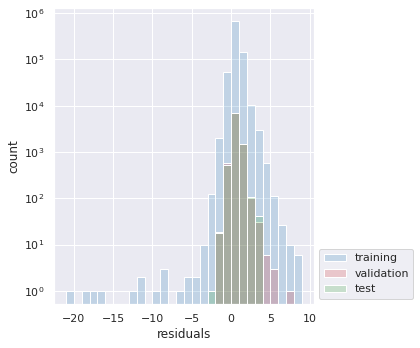

In [95]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h11',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h11',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h11',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

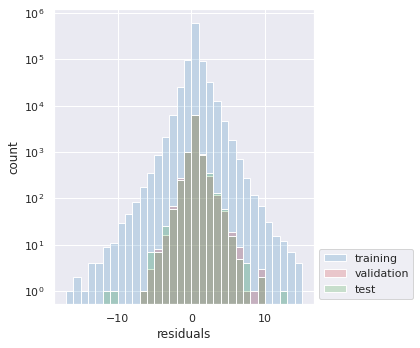

In [96]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h21',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h21',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h21',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

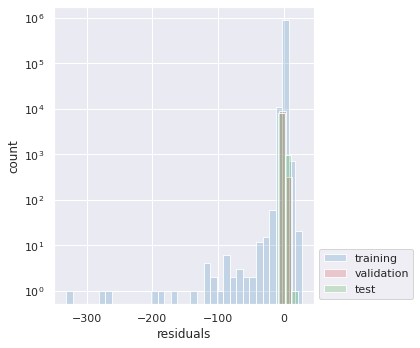

In [97]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h31',
             stat='count',
             color='tab:blue',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h31',
             stat='count',
             color='tab:red',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h31',
             stat='count',
             color='tab:green',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

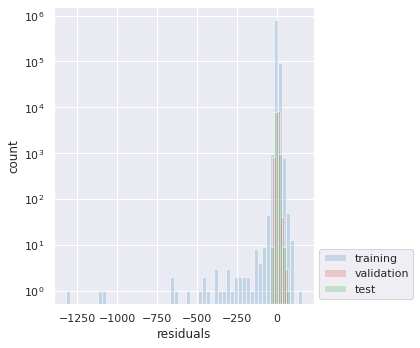

In [98]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h22',
             stat='count',
             color='tab:blue',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h22',
             stat='count',
             color='tab:red',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h22',
             stat='count',
             color='tab:green',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

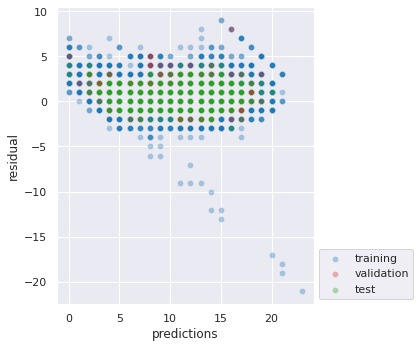

In [99]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

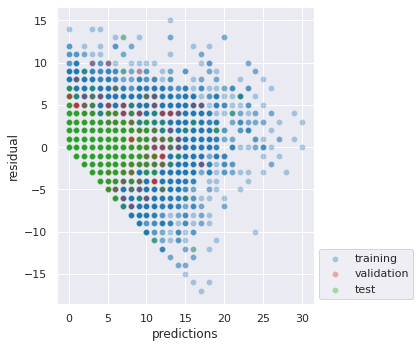

In [100]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

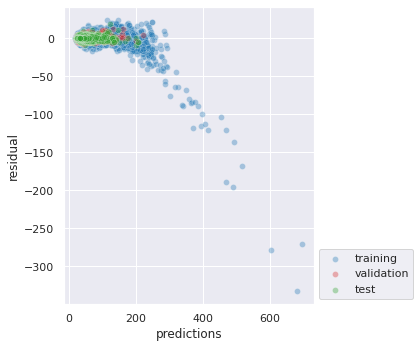

In [101]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

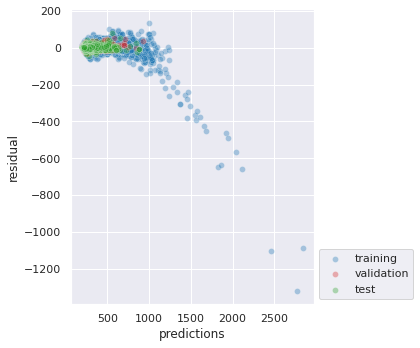

In [102]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '_h31_model.pdf'), format='pdf', dpi=150)

## Computing Metrics and Predictions for the Best $h^{2,2}$ Model

In [103]:
_ = full_h22_model.evaluate(x=test_features, y=test_labels, batch_size=batch_size, verbose=1)

142/142 [==============================] - 1s 6ms/step - loss: 16.7593 - h11_loss: 0.2792 - h21_loss: 0.9682 - h22_loss: 24.4590 - h31_loss: 1.5772 - h11_mean_squared_error: 0.2792 - h11_mean_absolute_error: 0.3681 - h21_mean_squared_error: 0.9682 - h21_mean_absolute_error: 0.4785 - h22_mean_squared_error: 24.4590 - h22_mean_absolute_error: 3.3646 - h31_mean_squared_error: 1.5772 - h31_mean_absolute_error: 0.8725


In [104]:
train_predictions = full_h22_model.predict(train_features)
train_predictions = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in train_predictions.items()}
val_predictions   = full_h22_model.predict(val_features)
val_predictions   = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in val_predictions.items()}
test_predictions  = full_h22_model.predict(test_features)
test_predictions  = {key: list(np.rint(value.reshape(-1,)).astype(np.float64)) for key, value in test_predictions.items()}

# save predictions to file
with open(pdata(PREFIX + 'train_predictions' + SUFFIX + '_h22_model.json'), 'w') as f:
    json.dump(train_predictions, f)
with open(pdata(PREFIX + 'val_predictions' + SUFFIX + '_h22_model.json'), 'w') as f:
    json.dump(val_predictions, f)
with open(pdata(PREFIX + 'test_predictions' + SUFFIX + '_h22_model.json'), 'w') as f:
    json.dump(test_predictions, f)

In [105]:
# compute metrics
metrics = {}
hodges  = ['h11', 'h21', 'h31', 'h22']
metrics['train_mse'] = [mean_squared_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mse']   = [mean_squared_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mse']  = [mean_squared_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_mae'] = [mean_absolute_error(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_mae']   = [mean_absolute_error(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_mae']  = [mean_absolute_error(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_r2']  = [r2_score(train_labels[c], train_predictions[c]) for c in hodges]
metrics['val_r2']    = [r2_score(val_labels[c], val_predictions[c]) for c in hodges]
metrics['test_r2']   = [r2_score(test_labels[c], test_predictions[c]) for c in hodges]
metrics['train_acc'] = [accuracy_score(train_labels[c], np.rint(train_predictions[c]).astype(np.int)) for c in hodges]
metrics['val_acc']   = [accuracy_score(val_labels[c], np.rint(val_predictions[c]).astype(np.int)) for c in hodges]
metrics['test_acc']  = [accuracy_score(test_labels[c], np.rint(test_predictions[c]).astype(np.int)) for c in hodges]

metrics = pd.DataFrame(metrics, index=hodges)
metrics.to_csv(pdata(PREFIX + 'metrics' + SUFFIX + '_h22_model.csv.gz'))
metrics

,train_mse,val_mse,test_mse,train_mae,val_mae,test_mae,train_r2,val_r2,test_r2,train_acc,val_acc,test_acc
h11,0.330954,0.339185,0.320746,0.267631,0.272055,0.260903,0.943684,0.940656,0.946557,0.756071,0.751905,0.762946
h21,0.963592,0.945015,1.004969,0.460742,0.459865,0.465496,0.728015,0.728848,0.715840,0.694020,0.691178,0.694601
h31,2.302511,1.630893,1.660594,0.837505,0.827316,0.835155,0.987771,0.990915,0.991253,0.413405,0.417136,0.411395
h22,33.177293,24.064591,24.569615,3.366297,3.319974,3.361709,0.986523,0.989733,0.990079,0.115592,0.122115,0.118582


In [106]:
train_residuals = {key: np.subtract(train_labels[key], train_predictions[key]) for key in train_labels.keys()}
val_residuals   = {key: np.subtract(val_labels[key], val_predictions[key]) for key in val_labels.keys()}
test_residuals  = {key: np.subtract(test_labels[key], test_predictions[key]) for key in test_labels.keys()}

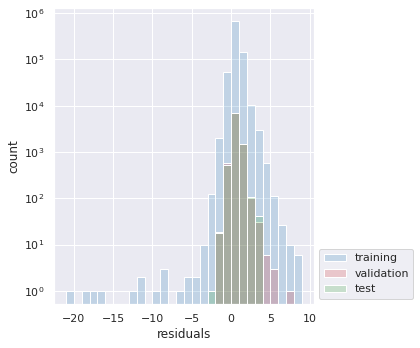

In [107]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h11',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h11',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h11',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals_hist' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

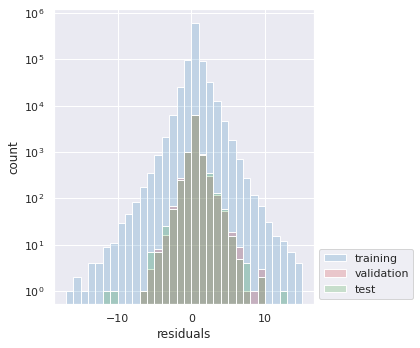

In [108]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h21',
             stat='count',
             color='tab:blue',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h21',
             stat='count',
             color='tab:red',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h21',
             stat='count',
             color='tab:green',
             binwidth=1,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals_hist' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

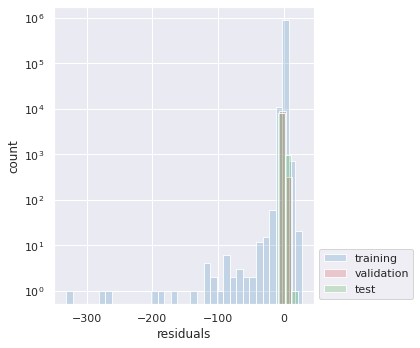

In [109]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h31',
             stat='count',
             color='tab:blue',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h31',
             stat='count',
             color='tab:red',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h31',
             stat='count',
             color='tab:green',
             binwidth=10,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals_hist' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

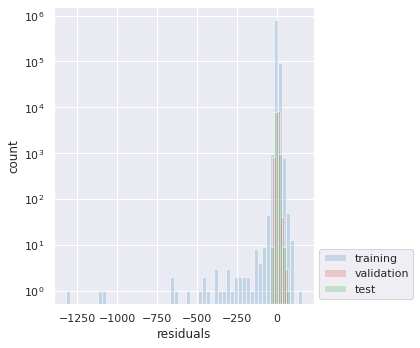

In [110]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(data=train_residuals,
             x='h22',
             stat='count',
             color='tab:blue',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=val_residuals,
             x='h22',
             stat='count',
             color='tab:red',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
sns.histplot(data=test_residuals,
             x='h22',
             stat='count',
             color='tab:green',
             binwidth=25,
             alpha=0.2,
             ax=ax
            )
ax.set_xlabel('residuals')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals_hist' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

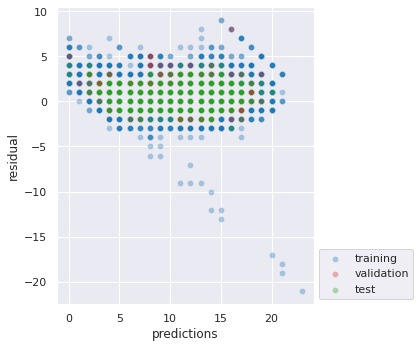

In [111]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h11'],
                y=train_residuals['h11'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h11'],
                y=val_residuals['h11'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h11'],
                y=test_residuals['h11'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h11_residuals' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

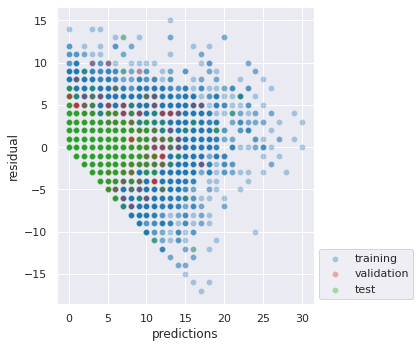

In [112]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h21'],
                y=train_residuals['h21'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h21'],
                y=val_residuals['h21'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h21'],
                y=test_residuals['h21'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h21_residuals' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

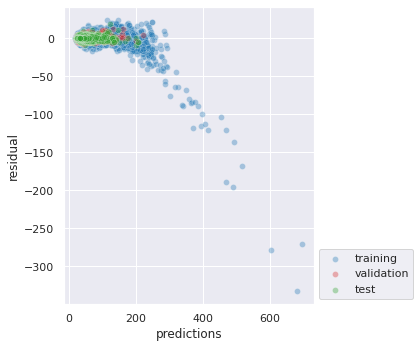

In [113]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h31'],
                y=train_residuals['h31'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h31'],
                y=val_residuals['h31'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h31'],
                y=test_residuals['h31'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h31_residuals' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)

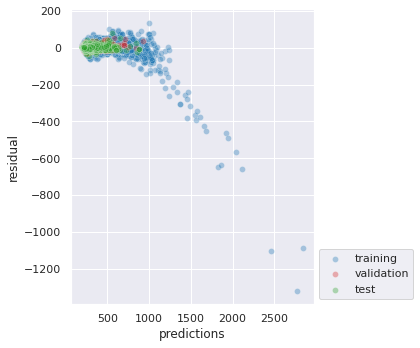

In [114]:
_, ax = plt.subplots(1, 1, figsize=(6,5))

sns.scatterplot(x=train_predictions['h22'],
                y=train_residuals['h22'],
                c=['tab:blue'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=val_predictions['h22'],
                y=val_residuals['h22'],
                c=['tab:red'],
                alpha=0.35,
                ax=ax
               )
sns.scatterplot(x=test_predictions['h22'],
                y=test_residuals['h22'],
                c=['tab:green'],
                alpha=0.35,
                ax=ax
               )
ax.set_xlabel('predictions')
ax.set_ylabel('residual')
ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.tight_layout()
plt.savefig(pimg(PREFIX + 'h22_residuals' + SUFFIX + '_h22_model.pdf'), format='pdf', dpi=150)